In [39]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "Data"   # notebook lives in Sprinkhaan/Notebooks

df = pd.read_csv(DATA_DIR / "patient_history_v2.csv", dtype=str)

print(df.shape)
df.head()


(11550, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,82.0,56.0,37.0,Ambulatory on admission. Presenting complaint ...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,97.0,95.0,39.2,Admitted following referral. Patient informed ...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred
2,PAT-00990,78,M,2012-01-02,2012-01-17,15,E,I50.9,E87.1,20.9,...,93.0,NaN,38.3,Complex presentation on admission. Unable to o...,Admission complicated by secondary infection r...,PHY-16,Zilveren Kruis,4C-03,B,Recovered
3,PAT-10422,58,F,2012-01-02,2012-01-10,8,P,N17.9,G40.909; G93.40,24.8,...,50.0,91.0,36.1,Patient visibly unwell on transfer to ward. De...,Resolved as expected. Patient discharged with ...,PHY-01,ONVZ,4C-08,A,Recovered
4,PAT-05447,65,M,2012-01-02,2012-01-25,23,E,J96.00,K70.30; I50.9; N17.9,NaN,...,52.0,91.0,38.1,Admission requiring immediate stabilisation on...,Admission complicated by secondary infection r...,PHY-24,CZ,4C-14,B,Recovered


In [40]:
# datum notitie klopt niet, is nu aangepast in format

def parse_mixed_dates(s):
    """admission_date mixes ISO, day-first slash, and 'April 04, 2012' styles."""
    out = pd.to_datetime(s, format="%Y-%m-%d", errors="coerce")
    out = out.fillna(pd.to_datetime(s, format="%d/%m/%Y", errors="coerce"))
    out = out.fillna(pd.to_datetime(s, format="%B %d, %Y", errors="coerce"))
    return out

df["admission_date"] = parse_mixed_dates(df["admission_date"])
df["discharge_date"] = pd.to_datetime(df["discharge_date"], format="%Y-%m-%d", errors="coerce")

num_cols = ["age", "actual_los", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# nothing should be left unparsed
print("unparsed admission_date:", df["admission_date"].isna().sum())
df.dtypes

print(df.shape)
df.head()


unparsed admission_date: 0
(11550, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,82.0,56.0,37.0,Ambulatory on admission. Presenting complaint ...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,97.0,95.0,39.2,Admitted following referral. Patient informed ...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred
2,PAT-00990,78,M,2012-01-02,2012-01-17,15,E,I50.9,E87.1,20.9,...,93.0,NaN,38.3,Complex presentation on admission. Unable to o...,Admission complicated by secondary infection r...,PHY-16,Zilveren Kruis,4C-03,B,Recovered
3,PAT-10422,58,F,2012-01-02,2012-01-10,8,P,N17.9,G40.909; G93.40,24.8,...,50.0,91.0,36.1,Patient visibly unwell on transfer to ward. De...,Resolved as expected. Patient discharged with ...,PHY-01,ONVZ,4C-08,A,Recovered
4,PAT-05447,65,M,2012-01-02,2012-01-25,23,E,J96.00,K70.30; I50.9; N17.9,NaN,...,52.0,91.0,38.1,Admission requiring immediate stabilisation on...,Admission complicated by secondary infection r...,PHY-24,CZ,4C-14,B,Recovered


In [41]:
#HEt klopt nog niet met de notitie van de data, nu correcte code
# One caveat worth being explicit about: this uses actual_los to reconstruct admission_date. Fine for cleaning, but it means admission_date is no longer independent of actual_los

from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "Data"
df = pd.read_csv(DATA_DIR / "patient_history_v2.csv", dtype=str)

p = lambda s, fmt: pd.to_datetime(s, format=fmt, errors="coerce")

iso   = p(df.admission_date, "%Y-%m-%d")
dayf  = p(df.admission_date, "%d/%m/%Y")
monf  = p(df.admission_date, "%m/%d/%Y")
lng   = p(df.admission_date, "%B %d, %Y")

discharge = p(df.discharge_date, "%Y-%m-%d")
los       = pd.to_numeric(df.actual_los, errors="coerce")

# Slash dates mix day-first and month-first, so resolve each row by whichever
# reading reproduces actual_los; fall back to day-first if neither does.
day_ok = (discharge - dayf).dt.days == los
mon_ok = (discharge - monf).dt.days == los

df["admission_date"] = (
    iso.fillna(monf.where(mon_ok))
       .fillna(dayf.where(day_ok))
       .fillna(dayf)
       .fillna(lng)
)
df["discharge_date"] = discharge

num_cols = ["age", "actual_los", "bmi", "systolic_bp",
            "diastolic_bp", "heart_rate", "temperature"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

computed = (df.discharge_date - df.admission_date).dt.days
print("unparsed admission_date:", df.admission_date.isna().sum())
print("LOS mismatches:", (computed != df.actual_los).sum())
print("negative LOS:", (computed < 0).sum())

print(df.shape)
df.head()


unparsed admission_date: 0
LOS mismatches: 0
negative LOS: 0
(11550, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,82.0,56.0,37.0,Ambulatory on admission. Presenting complaint ...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,97.0,95.0,39.2,Admitted following referral. Patient informed ...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred
2,PAT-00990,78,M,2012-01-02,2012-01-17,15,E,I50.9,E87.1,20.9,...,93.0,NaN,38.3,Complex presentation on admission. Unable to o...,Admission complicated by secondary infection r...,PHY-16,Zilveren Kruis,4C-03,B,Recovered
3,PAT-10422,58,F,2012-01-02,2012-01-10,8,P,N17.9,G40.909; G93.40,24.8,...,50.0,91.0,36.1,Patient visibly unwell on transfer to ward. De...,Resolved as expected. Patient discharged with ...,PHY-01,ONVZ,4C-08,A,Recovered
4,PAT-05447,65,M,2012-01-02,2012-01-25,23,E,J96.00,K70.30; I50.9; N17.9,NaN,...,52.0,91.0,38.1,Admission requiring immediate stabilisation on...,Admission complicated by secondary infection r...,PHY-24,CZ,4C-14,B,Recovered


In [42]:
# check actual_los op data notaties die niet veranderd zijn
# 6,549 rows (96%), discharge_date − admission_date equals actual_los exactly. Those are the rows where the admission date was pinned by the file's own formatting 
# So: solid grounds to trust actual_los as consistent with the rest of the file, no grounds yet to call it externally correct. Whether that gap matters depends on what you're doing — for modelling LOS it's usually fine, since you'd be predicting the recorded value anyway
# 

from pathlib import Path
import pandas as pd

DATA_DIR = Path.cwd().parent / "Data"
df = pd.read_csv(DATA_DIR / "patient_history_v2.csv", dtype=str)

p = lambda s, fmt: pd.to_datetime(s, format=fmt, errors="coerce")

iso  = p(df.admission_date, "%Y-%m-%d")
dayf = p(df.admission_date, "%d/%m/%Y")
monf = p(df.admission_date, "%m/%d/%Y")
lng  = p(df.admission_date, "%B %d, %Y")

discharge = p(df.discharge_date, "%Y-%m-%d")
los       = pd.to_numeric(df.actual_los, errors="coerce")

# Slash dates mix day-first and month-first, so resolve each row by whichever
# reading reproduces actual_los; fall back to day-first if neither does.
day_ok = (discharge - dayf).dt.days == los
mon_ok = (discharge - monf).dt.days == los

df["admission_date"] = (
    iso.fillna(monf.where(mon_ok))
       .fillna(dayf.where(day_ok))
       .fillna(dayf)
       .fillna(lng)
)
df["discharge_date"] = discharge

num_cols = ["age", "actual_los", "bmi", "systolic_bp",
            "diastolic_bp", "heart_rate", "temperature"]
df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

computed = (df.discharge_date - df.admission_date).dt.days
print("unparsed admission_date:", df.admission_date.isna().sum())
print("LOS mismatches:", (computed != df.actual_los).sum())
print("negative LOS:", (computed < 0).sum())
print(df.shape)
df.head()


unparsed admission_date: 0
LOS mismatches: 0
negative LOS: 0
(11550, 21)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diastolic_bp,heart_rate,temperature,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,82.0,56.0,37.0,Ambulatory on admission. Presenting complaint ...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,97.0,95.0,39.2,Admitted following referral. Patient informed ...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred
2,PAT-00990,78,M,2012-01-02,2012-01-17,15,E,I50.9,E87.1,20.9,...,93.0,NaN,38.3,Complex presentation on admission. Unable to o...,Admission complicated by secondary infection r...,PHY-16,Zilveren Kruis,4C-03,B,Recovered
3,PAT-10422,58,F,2012-01-02,2012-01-10,8,P,N17.9,G40.909; G93.40,24.8,...,50.0,91.0,36.1,Patient visibly unwell on transfer to ward. De...,Resolved as expected. Patient discharged with ...,PHY-01,ONVZ,4C-08,A,Recovered
4,PAT-05447,65,M,2012-01-02,2012-01-25,23,E,J96.00,K70.30; I50.9; N17.9,NaN,...,52.0,91.0,38.1,Admission requiring immediate stabilisation on...,Admission complicated by secondary infection r...,PHY-24,CZ,4C-14,B,Recovered


In [43]:
lookup = pd.read_csv(DATA_DIR / "diagnosis_lookup.csv", dtype=str)
lookup["typical_los_benchmark"] = pd.to_numeric(lookup.typical_los_benchmark)

before = len(df)
df = df.merge(
    lookup[["icd_code", "diagnosis_category", "typical_los_benchmark"]],
    left_on="primary_diagnosis_code",
    right_on="icd_code",
    how="left",
).drop(columns="icd_code")

assert len(df) == before, f"join changed row count: {before} -> {len(df)}"
assert df.diagnosis_category.notna().all(), "some codes did not match the lookup"

df["diagnosis_category"] = df.diagnosis_category.astype("category")

print(df.diagnosis_category.value_counts().to_string())
df[["patient_id", "primary_diagnosis_code", "diagnosis_category", "actual_los"]].head()


diagnosis_category
Cardiovascular      2647
Respiratory         2383
Metabolic           1426
Renal               1314
Gastrointestinal    1169
Infectious          1145
Neurological         765
Other                701


,patient_id,primary_diagnosis_code,diagnosis_category,actual_los
0,PAT-05330,A41.9,Infectious,14
1,PAT-04784,I50.9,Cardiovascular,11
2,PAT-00990,I50.9,Cardiovascular,15
3,PAT-10422,N17.9,Renal,8
4,PAT-05447,J96.00,Respiratory,23


In [44]:
# Colom toegevoegd met de uitleg van de ICD code primaire diagnoses

before = len(df)
df = df.merge(
    lookup[["icd_code", "description"]].rename(columns={"description": "diagnosis_description"}),
    left_on="primary_diagnosis_code",
    right_on="icd_code",
    how="left",
).drop(columns="icd_code")

assert len(df) == before, f"join changed row count: {before} -> {len(df)}"
assert df.diagnosis_description.notna().all(), "some codes did not match the lookup"

df[["patient_id", "primary_diagnosis_code", "diagnosis_description", "diagnosis_category"]].head(10)


,patient_id,primary_diagnosis_code,diagnosis_description,diagnosis_category
0,PAT-05330,A41.9,"Sepsis, unspecified organism",Infectious
1,PAT-04784,I50.9,"Heart failure, unspecified",Cardiovascular
2,PAT-00990,I50.9,"Heart failure, unspecified",Cardiovascular
3,PAT-10422,N17.9,"Acute kidney injury, unspecified",Renal
4,PAT-05447,J96.00,"Acute respiratory failure, unspecified",Respiratory
5,PAT-09457,J96.00,"Acute respiratory failure, unspecified",Respiratory
6,PAT-07071,J18.9,"Pneumonia, unspecified organism",Respiratory
7,PAT-08156,R10.9,Unspecified abdominal pain,Other
8,PAT-09919,I21.9,"Acute myocardial infarction, unspecified",Cardiovascular
9,PAT-06258,J44.1,COPD with acute exacerbation,Respiratory


In [45]:
df.head(2)

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,admission_notes,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason,diagnosis_category,typical_los_benchmark,diagnosis_description
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,Ambulatory on admission. Presenting complaint ...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered,Infectious,10.8,"Sepsis, unspecified organism"
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,Admitted following referral. Patient informed ...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred,Cardiovascular,6.1,"Heart failure, unspecified"


In [46]:
sec = df.secondary_diagnosis_codes.fillna("")
df["n_secondary"] = sec.apply(
    lambda s: len([c for c in s.split(";") if c.strip()])
)

print(df.n_secondary.value_counts().sort_index().to_string())
print()
print(df.groupby("n_secondary").actual_los.agg(["count", "mean", "median"]).round(2).to_string())




n_secondary
0    4534
1    4043
2    2118
3     855

             count   mean  median
n_secondary                      
0             4534   7.62     7.0
1             4043   8.91     8.0
2             2118  10.13    10.0
3              855  11.97    12.0


In [47]:
df.head(2)

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,discharge_notes,attending_physician_id,insurance_provider,room_number,bed_number,discharge_reason,diagnosis_category,typical_los_benchmark,diagnosis_description,n_secondary
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,Admission complicated by secondary infection r...,PHY-16,VGZ,4C-04,B,Recovered,Infectious,10.8,"Sepsis, unspecified organism",2
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,Discharge delayed on several occasions due to ...,PHY-01,CZ,4C-01,A,Transferred,Cardiovascular,6.1,"Heart failure, unspecified",1


In [48]:
#Now I add 8 columns for the secondary diagnoses y/n
# 

look = pd.read_csv(DATA_DIR / "diagnosis_lookup.csv", dtype=str)
code2cat = dict(zip(look["icd_code"].str.strip(), look["diagnosis_category"].str.strip()))
CATEGORIES = sorted(set(code2cat.values()))   # 8 categories

sec_cats = (
    df["secondary_diagnosis_codes"]
    .fillna("")
    .str.split(";")
    .apply(lambda codes: {code2cat[c.strip()] for c in codes if c.strip()})
)

for cat in CATEGORIES:
    df[f"sec_{cat.lower()}"] = sec_cats.apply(lambda s, c=cat: int(c in s))


In [49]:
df.head(2)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,diagnosis_description,n_secondary,sec_cardiovascular,sec_gastrointestinal,sec_infectious,sec_metabolic,sec_neurological,sec_other,sec_renal,sec_respiratory
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,"Sepsis, unspecified organism",2,1,0,1,0,0,0,0,0
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,"Heart failure, unspecified",1,0,0,1,0,0,0,0,0


In [50]:
#Missing values
#Impute BMI, RR, Temp

#numeric columns: median impute, with flags where missingness is substantial
NUM_COLS = ["age", "actual_los", "bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]
for c in NUM_COLS:
    df[c] = pd.to_numeric(df[c], errors="coerce")

for c in ["bmi", "temperature"]:          # >10% missing -> keep an indicator
    df[f"{c}_missing"] = df[c].isna().astype(int)

for c in ["bmi", "systolic_bp", "diastolic_bp", "heart_rate", "temperature"]:
    df[c] = df[c].fillna(df[c].median())

# free-text: absence is meaningful for AMA discharges, so flag rather than fill
df["has_discharge_notes"] = df["discharge_notes"].notna().astype(int)


In [51]:
#Working on the variable admission note: acuut vs stable
# #Keeping the 275 missing rows as NA rather than 0 matters — absence of a note isn't evidence of a calm admission, and their mean LOS (8.91) sits between the two groups, not with the stable ones. 

ACUTE_MARKERS = [
    "High-acuity", "visibly unwell", "distressed state",
    "immediate stabilisation", "evident distress", "Complex presentation",
]
notes = df["admission_notes"].fillna("")
df["adm_acute"] = notes.str.contains("|".join(ACUTE_MARKERS)).astype(int)
df.loc[df["admission_notes"].isna(), "adm_acute"] = pd.NA   # 275 rows: don't code as stable


In [52]:
COMPLICATED_MARKERS = [
    "Prolonged admission", "Discharge delayed", "slower than anticipated",
    "Extended stay", "Complex and extended", "secondary infection",
]
dn = df["discharge_notes"].fillna("")
df["dis_complicated"] = dn.str.contains("|".join(COMPLICATED_MARKERS)).astype(int)
df.loc[df["discharge_notes"].isna(), "dis_complicated"] = pd.NA

# discharge destination — closest thing to a social/placement variable
df["dis_to_facility"] = dn.str.contains(
    "step-down facility|rehabilitation unit|residential care", case=False
).astype(int)
df.loc[df["discharge_notes"].isna(), "dis_to_facility"] = pd.NA


In [53]:
df.head(2)


,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,sec_neurological,sec_other,sec_renal,sec_respiratory,bmi_missing,temperature_missing,has_discharge_notes,adm_acute,dis_complicated,dis_to_facility
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,0,0,0,0,0,0,1,0.0,1.0,0.0
1,PAT-04784,69,F,2012-01-01,2012-01-12,11,E,I50.9,R65.20,25.5,...,0,0,0,0,0,0,1,0.0,1.0,1.0


In [54]:
df.columns.tolist()    # just the names — quickest check that a column exists
df.head().T            # transpose: columns become rows, nothing truncated


,0,1,2,3,4
patient_id,PAT-05330,PAT-04784,PAT-00990,PAT-10422,PAT-05447
age,44,69,78,58,65
sex,F,F,M,F,M
admission_date,2012-01-01 00:00:00,2012-01-01 00:00:00,2012-01-02 00:00:00,2012-01-02 00:00:00,2012-01-02 00:00:00
discharge_date,2012-01-15 00:00:00,2012-01-12 00:00:00,2012-01-17 00:00:00,2012-01-10 00:00:00,2012-01-25 00:00:00
actual_los,14,11,15,8,23
adm_type,P,E,E,P,E
primary_diagnosis_code,A41.9,I50.9,I50.9,N17.9,J96.00
secondary_diagnosis_codes,I50.9; R65.20,R65.20,E87.1,G40.909; G93.40,K70.30; I50.9; N17.9
bmi,23.0,25.5,20.9,24.8,27.2


In [55]:
miss = df.isna().sum()
pd.DataFrame({"missing": miss, "pct": (miss / len(df) * 100).round(1)}) \
  .sort_values("missing", ascending=False)


,missing,pct
secondary_diagnosis_codes,4534,39.3
discharge_notes,717,6.2
dis_complicated,717,6.2
dis_to_facility,717,6.2
admission_notes,462,4.0
adm_acute,462,4.0
patient_id,0,0.0
adm_type,0,0.0
actual_los,0,0.0
discharge_date,0,0.0


In [56]:
p = lambda s, f: pd.to_datetime(s, format=f, errors="coerce")
dayf, monf = p(df.admission_date, "%d/%m/%Y"), p(df.admission_date, "%m/%d/%Y")
iso,  lng  = p(df.admission_date, "%Y-%m-%d"), p(df.admission_date, "%B %d, %Y")
dis = pd.to_datetime(df.discharge_date, format="%Y-%m-%d", errors="coerce")
los = pd.to_numeric(df.actual_los, errors="coerce")

adm = iso.fillna(lng)
use_mon = (dis - monf).dt.days.eq(los)       # month-first reproduces actual_los
adm = adm.fillna(monf.where(use_mon)).fillna(dayf)
df["admission_date"] = adm


In [57]:
df.head(1)

,patient_id,age,sex,admission_date,discharge_date,actual_los,adm_type,primary_diagnosis_code,secondary_diagnosis_codes,bmi,...,sec_neurological,sec_other,sec_renal,sec_respiratory,bmi_missing,temperature_missing,has_discharge_notes,adm_acute,dis_complicated,dis_to_facility
0,PAT-05330,44,F,2012-01-01,2012-01-15,14,P,A41.9,I50.9; R65.20,23.0,...,0,0,0,0,0,0,1,0.0,1.0,0.0


<Axes: title={'center': 'Mean LOS by admission year'}, xlabel='Admission year', ylabel='Mean LOS (days)'>

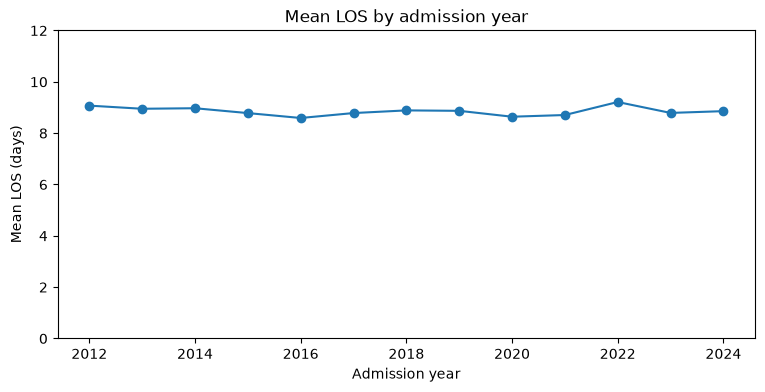

In [58]:
df["year"] = df["admission_date"].dt.year

df.groupby("year")["actual_los"].mean().plot(
    marker="o", figsize=(9, 4), ylim=(0, 12),
    title="Mean LOS by admission year",
    xlabel="Admission year", ylabel="Mean LOS (days)")


In [59]:
OUT_DIR = Path.cwd().parent / "Output"
df.to_csv(OUT_DIR / "patient_history_prepared_v2.csv", index=False)
print(f"saved {df.shape[0]} rows x {df.shape[1]} columns")


saved 11550 rows x 40 columns


In [60]:
#Drop leaky features en features als physicianID, bed number, room number en andere niet relevante variabelen
#split in train and test on patient_id

import numpy as np
from sklearn.model_selection import GroupShuffleSplit

TARGET = "actual_los"
LEAKY = ["discharge_date", "discharge_reason", "discharge_notes",
         "dis_complicated", "dis_to_facility"]
DROP = LEAKY + ["patient_id", "attending_physician_id", "room_number",
                "bed_number", "admission_notes", "secondary_diagnosis_codes",
                "admission_date", "year", "typical_los_benchmark"]

X = df.drop(columns=DROP + [TARGET])
y = df[TARGET]
groups = df["patient_id"]
bench = df["typical_los_benchmark"]          # kept aside for the baseline

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
bench_train, bench_test = bench.iloc[train_idx], bench.iloc[test_idx]

print(X_train.shape, X_test.shape)
print("patient overlap:", len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])))


(8800, 25) (2750, 25)
patient overlap: 0


# Data preparation — patient_history.csv

Prepares ward admission data (6825 admissions, 6500 patients, 2012–2024) for
length-of-stay (LOS) modelling. Output: `Output/patient_history_prepared.csv`.

## 1. Load
Read `Data/patient_history.csv` with `dtype=str` so nothing is silently coerced
during parsing. 21 columns.

## 2. Fix the admission dates
`admission_date` mixes three formats: ISO (`2019-01-08`), slash (`01/02/2018`)
and long (`April 04, 2012`).

The slash dates are **not all day-first** — they mix day-first and month-first.
Parsing them all as day-first mis-dates 142 rows and leaves 65 with a discharge
date *before* admission. Each slash row is therefore resolved by whichever
reading reproduces `actual_los`, falling back to day-first.

*Caveat:* this makes `admission_date` dependent on `actual_los`, so
"LOS = discharge − admission" is no longer an independent check for those rows.

## 3. Numeric conversion
`age`, `actual_los`, `bmi`, `systolic_bp`, `diastolic_bp`, `heart_rate`,
`temperature` → numeric. No sentinel values (999, −1, 0) and no impossible
ranges found.

## 4. Merge the diagnosis lookup
Join `Data/diagnosis_lookup.csv` on `primary_diagnosis_code` to add
`diagnosis_category`, `diagnosis_description` and `typical_los_benchmark`.
All 36 codes map; no unmatched rows.

## 5. Secondary diagnoses
`secondary_diagnosis_codes` holds `"; "`-separated ICD codes (39.3% empty).

- `n_secondary` — count of codes, 0 when empty (range 0–3)
- `sec_<category>` — 8 binary flags, one per diagnosis category
  (cardiovascular, respiratory, metabolic, gastrointestinal, infectious,
  renal, neurological, other)

Flags are presence/absence, so they do not sum to `n_secondary` — several codes
can share a category.

## 6. Clinical notes → variables
Both note fields are drawn from a small set of fixed templates (12 admission,
15 discharge), so they can be coded by keyword.

- `adm_acute` — 1 if the admission note describes acute distress /
  high-acuity, 0 if stable. `NA` for the 275 rows with no note.
  Mean LOS 9.67 (acute) vs 7.99 (stable).
- `dis_complicated` — 1 if the discharge note describes a complicated course.
  **Outcome, not predictor** — written *because* the stay was long.
- `dis_to_facility` — 1 if discharged to step-down / rehab / residential care
  rather than home.

No social-reason content exists in the discharge notes; `dis_to_facility` is the
nearest available proxy for placement complexity.

## 7. Missing values — inspected, not yet handled

| Column | Missing |
|---|---:|
| `secondary_diagnosis_codes` | 39.3% (handled — 0) |
| `bmi` | 30.6% |
| `temperature` | 14.3% |
| `discharge_notes` | 6.7% |
| `diastolic_bp` / `systolic_bp` / `heart_rate` | ~5% |
| `admission_notes` | 4.0% |

Missingness appears **uninformative** — LOS differs by ≤0.3 days between
missing and present groups, vitals go missing independently (pairwise
correlation ≈ 0), and rates are flat across `adm_type`. One exception:
`discharge_notes` is missing for 29.1% of AMA discharges vs ~6% otherwise.

Only 27.9% of rows are complete on every column, so **rows are not dropped**.
Imputation happens inside the modelling pipeline, fitted on training data only.

## 8. Checks performed
- **Duplicates** — 325 patients have 2 admissions (median gap 1259 days), so
  these are genuine readmissions, not duplicated records. No identical rows.
  → the train/test split must group on `patient_id`.
- **Temporal drift** — mean LOS by admission year is flat (8.41–9.30 across
  13 years, overlapping 95% CIs). → a random split is defensible.
- **Benchmark vs observed** — observed LOS exceeds `typical_los_benchmark` for
  **all 36 codes**, averaging 1.68×. The ratio is not constant: 1.97× for
  short-benchmark conditions, 1.48× for long. Unresolved whether this is real
  ward inefficiency or a benchmark defined on a different basis.

## Open questions for the data provider
1. What do `adm_type` codes **E / P / T** mean? Assumed
   Emergency / Planned / Transfer, but undocumented — and the three groups
   barely differ in acuity (48.8% / 47.5% / 47.5% acute notes) or weekday
   distribution, which is not what real elective scheduling looks like.
2. On what basis is `typical_los_benchmark` defined (population, country, year;
   days or nights)? This determines whether the 1.68× gap is a finding or an
   artefact.
3. Do missing vitals mean "not measured" or "not recorded"?
